# Credit Risk Analysis and Modeling - Final Enhanced Workflow

This notebook includes:
- stronger hyperparameter tuning
- a cleaner final model-selection workflow
- cross-validation checks
- SHAP-based interpretation
- final tree-model importance for reporting

In [28]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import gc
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="pastel")

# Display helpers
from IPython.display import display, Markdown

# Modeling
from sklearn import preprocessing
from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    learning_curve,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score
)

import lightgbm as lgb
import xgboost as xgb
import shap

from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Data loading

**Idea:** load train and test data from either local paths or relative project paths so the notebook is easier to run on another machine.

In [29]:
# Update these paths if your dataset is stored somewhere else.
TRAIN_CANDIDATES = [
    Path(r"D:/AI_ML/New_repo/fantastic-pancake/data/application_train.csv/application_train.csv"),
    Path("data/application_train.csv"),
    Path("application_train.csv"),
]

TEST_CANDIDATES = [
    Path(r"D:/AI_ML/New_repo/fantastic-pancake/data/application_test.csv/application_test.csv"),
    Path("/content/application_train.csv"),
    Path("application_test.csv"),
]

def resolve_existing_path(candidates):
    for path in candidates:
        if Path(path).exists():
            return Path(path)
    raise FileNotFoundError(
        "Dataset file not found. Please update TRAIN_CANDIDATES / TEST_CANDIDATES with the correct path."
    )

train_path = resolve_existing_path(TRAIN_CANDIDATES)
test_path = resolve_existing_path(TEST_CANDIDATES)

df_train = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

display(Markdown(f"**Train path:** `{train_path}`"))
display(Markdown(f"**Test path:** `{test_path}`"))
print("Train shape:", df_train.shape)
print("Test shape :", test_df.shape)

display(df_train.head())

**Train path:** `application_train.csv`

**Test path:** `/content/application_train.csv`

Train shape: (307511, 122)
Test shape : (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Quick project overview

**Idea:** get a quick feel for size, target balance, and missingness before modeling.

In [30]:
summary_df = pd.DataFrame({
    "rows": [df_train.shape[0], test_df.shape[0]],
    "columns": [df_train.shape[1], test_df.shape[1]],
    "missing_cells": [df_train.isna().sum().sum(), test_df.isna().sum().sum()]
}, index=["train", "test"])

display(summary_df)

target_dist = (
    df_train["TARGET"]
    .value_counts(normalize=True)
    .rename_axis("TARGET")
    .reset_index(name="ratio")
)
target_dist["percent"] = (target_dist["ratio"] * 100).round(2)
display(target_dist)

,rows,columns,missing_cells
train,307511,122,9152465
test,307511,122,9152465


,TARGET,ratio,percent
0,0,0.919271,91.93
1,1,0.080729,8.07


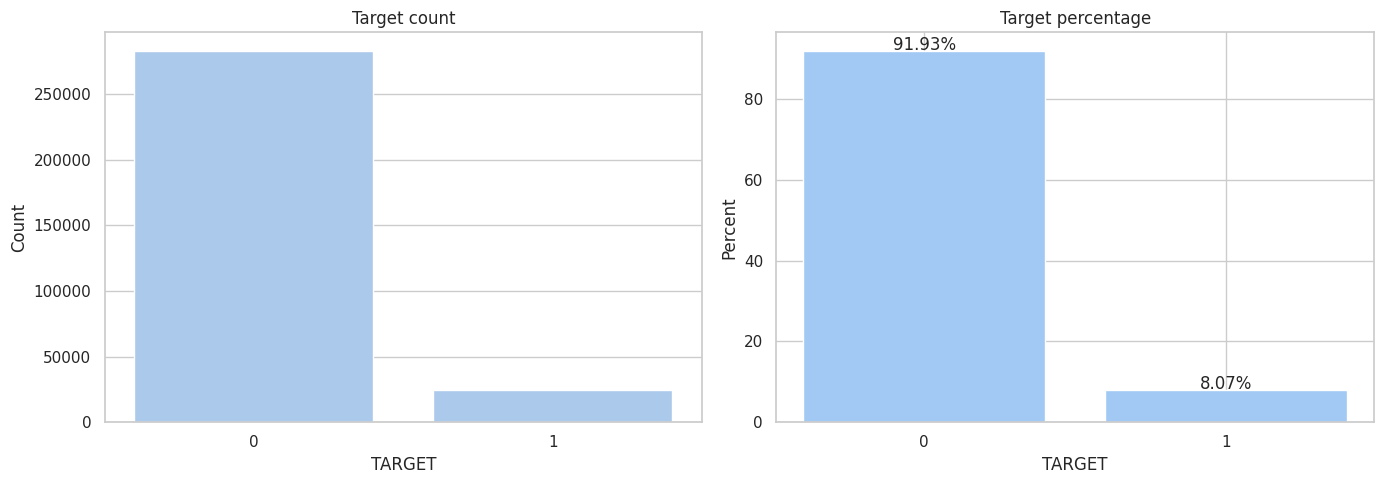

In [31]:
# Output distribution: this makes the class imbalance easy to see.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_train, x="TARGET", ax=axes[0])
axes[0].set_title("Target count")
axes[0].set_xlabel("TARGET")
axes[0].set_ylabel("Count")

target_plot = df_train["TARGET"].value_counts(normalize=True).sort_index() * 100
axes[1].bar(target_plot.index.astype(str), target_plot.values)
axes[1].set_title("Target percentage")
axes[1].set_xlabel("TARGET")
axes[1].set_ylabel("Percent")
for i, v in enumerate(target_plot.values):
    axes[1].text(i, v + 0.2, f"{v:.2f}%", ha="center")

plt.tight_layout()
plt.show()

,feature,missing_percent
0,COMMONAREA_AVG,69.872297
1,COMMONAREA_MODE,69.872297
2,COMMONAREA_MEDI,69.872297
3,NONLIVINGAPARTMENTS_MEDI,69.432963
4,NONLIVINGAPARTMENTS_MODE,69.432963
5,NONLIVINGAPARTMENTS_AVG,69.432963
6,FONDKAPREMONT_MODE,68.386172
7,LIVINGAPARTMENTS_AVG,68.354953
8,LIVINGAPARTMENTS_MEDI,68.354953
9,LIVINGAPARTMENTS_MODE,68.354953


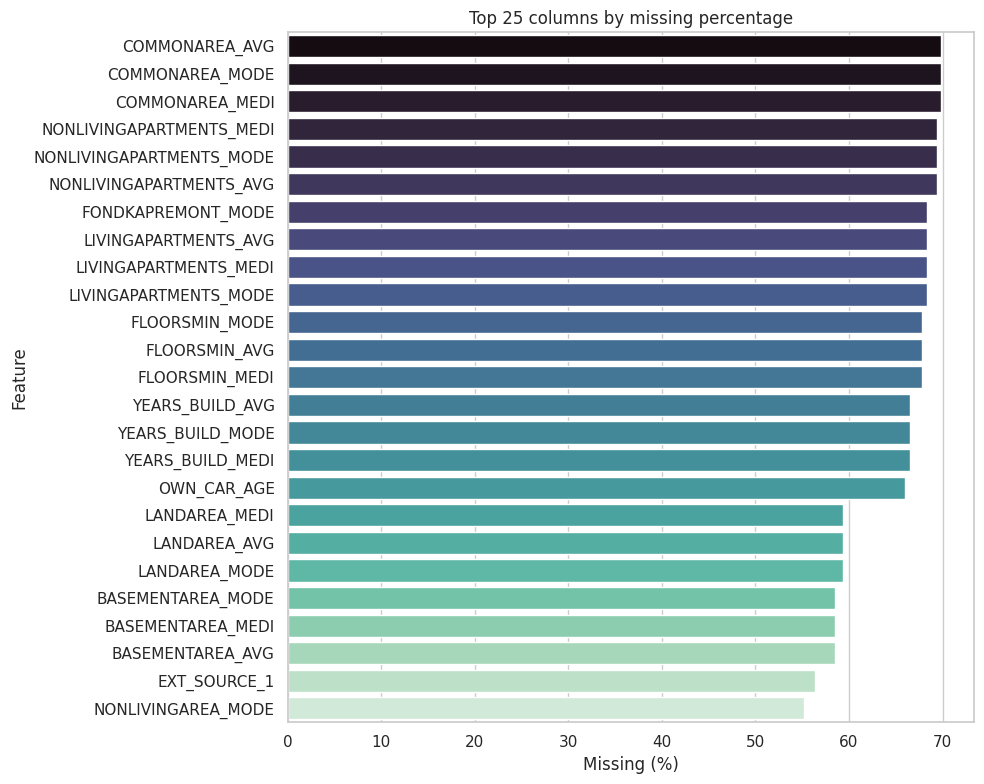

In [32]:
# Show the columns with the highest missing percentage.
missing_pct = (df_train.isna().mean() * 100).sort_values(ascending=False)
missing_top = missing_pct.head(25).reset_index()
missing_top.columns = ["feature", "missing_percent"]

display(missing_top)

plt.figure(figsize=(10, 8))
sns.barplot(data=missing_top, x="missing_percent", y="feature", palette="mako")
plt.title("Top 25 columns by missing percentage")
plt.xlabel("Missing (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 3. Anomaly handling and feature engineering

**Idea:** clean known day-based anomalies and add stronger ratio / aggregation features that are useful in credit-risk data.

In [33]:
# Work on copies so the flow stays clear.
train_fe = df_train.copy()
test_fe = test_df.copy()

# Convert day-based columns to positive day counts for easier reading.
day_cols = [
    "DAYS_BIRTH", "DAYS_EMPLOYED", "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH", "DAYS_LAST_PHONE_CHANGE"
]
for col in day_cols:
    if col in train_fe.columns:
        train_fe[col] = train_fe[col].abs()
    if col in test_fe.columns:
        test_fe[col] = test_fe[col].abs()

# Known anomaly in Home Credit data.
for df in [train_fe, test_fe]:
    df["EMPLOYED_ANOM"] = (df["DAYS_EMPLOYED"] == 365243).astype(int)
    df.loc[df["DAYS_EMPLOYED"] == 365243, "DAYS_EMPLOYED"] = np.nan

print("EMPLOYED_ANOM counts in train:")
display(train_fe["EMPLOYED_ANOM"].value_counts(dropna=False).to_frame("count"))

EMPLOYED_ANOM counts in train:


,count
EMPLOYED_ANOM,
0,252137
1,55374


In [34]:
# Existing + new engineered features
def add_features(df):
    ext_cols = [c for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"] if c in df.columns]
    doc_cols = [c for c in df.columns if c.startswith("FLAG_DOCUMENT_")]

    # Convert 'Y'/'N' flags to 1/0 for relevant columns before summing
    for col in ["FLAG_OWN_CAR", "FLAG_OWN_REALTY"]:
        if col in df.columns and df[col].dtype == 'object':
            df[col] = df[col].map({'Y': 1, 'N': 0}).fillna(0).astype(int)

    bureau_cols = [c for c in df.columns if c.startswith("AMT_REQ_CREDIT_BUREAU_")]
    live_flag_cols = [c for c in df.columns if c.startswith("FLAG_") and "DOCUMENT" not in c]

    # Basic credit burden
    df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / (df["AMT_INCOME_TOTAL"] + 1)
    df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / (df["AMT_INCOME_TOTAL"] + 1)
    df["CREDIT_TERM"] = df["AMT_ANNUITY"] / (df["AMT_CREDIT"] + 1)
    df["GOODS_CREDIT_RATIO"] = df["AMT_GOODS_PRICE"] / (df["AMT_CREDIT"] + 1)
    df["GOODS_INCOME_RATIO"] = df["AMT_GOODS_PRICE"] / (df["AMT_INCOME_TOTAL"] + 1)
    df["PAYMENT_RATE"] = df["AMT_ANNUITY"] / (df["AMT_CREDIT"] + 1)

    # Family / household burden
    if "CNT_FAM_MEMBERS" in df.columns:
        df["INCOME_PER_PERSON"] = df["AMT_INCOME_TOTAL"] / (df["CNT_FAM_MEMBERS"] + 1)
        df["CREDIT_PER_PERSON"] = df["AMT_CREDIT"] / (df["CNT_FAM_MEMBERS"] + 1)
    if "CNT_CHILDREN" in df.columns:
        df["INCOME_PER_CHILD"] = df["AMT_INCOME_TOTAL"] / (df["CNT_CHILDREN"] + 1)

    # Time and stability
    df["YEARS_BIRTH"] = df["DAYS_BIRTH"] / 365
    df["YEARS_EMPLOYED"] = df["DAYS_EMPLOYED"] / 365
    df["DAYS_EMPLOYED_RATIO"] = df["DAYS_EMPLOYED"] / (df["DAYS_BIRTH"] + 1)

    # Log transforms help with skewed financial columns.
    for col in ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]:
        if col in df.columns:
            df[f"LOG_{col}"] = np.log1p(df[col].clip(lower=0))

    # EXT_SOURCE aggregations
    if len(ext_cols) > 0:
        df["EXT_SOURCE_MEAN"] = df[ext_cols].mean(axis=1)
        df["EXT_SOURCE_STD"] = df[ext_cols].std(axis=1)
        df["EXT_SOURCE_MIN"] = df[ext_cols].min(axis=1)
        df["EXT_SOURCE_MAX"] = df[ext_cols].max(axis=1)
        df["EXT_SOURCE_RANGE"] = df["EXT_SOURCE_MAX"] - df["EXT_SOURCE_MIN"]
        df["EXT_SOURCE_PROD"] = df[ext_cols].prod(axis=1)
        df["EXT_SOURCE_MISSING_COUNT"] = df[ext_cols].isna().sum(axis=1)

    # Aggregate sparse groups into simple signals.
    if len(doc_cols) > 0:
        df["DOC_FLAGS_SUM"] = df[doc_cols].sum(axis=1)
    if len(bureau_cols) > 0:
        df["AMT_REQ_BUREAU_TOTAL"] = df[bureau_cols].sum(axis=1)
    if len(live_flag_cols) > 0:
        df["LIVE_FLAG_SUM"] = df[live_flag_cols].sum(axis=1)

    return df

train_fe = add_features(train_fe)
test_fe = add_features(test_fe)

new_feature_candidates = [
    "CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "CREDIT_TERM",
    "GOODS_CREDIT_RATIO", "GOODS_INCOME_RATIO", "PAYMENT_RATE",
    "INCOME_PER_PERSON", "CREDIT_PER_PERSON", "INCOME_PER_CHILD",
    "YEARS_BIRTH", "YEARS_EMPLOYED", "DAYS_EMPLOYED_RATIO",
    "LOG_AMT_INCOME_TOTAL", "LOG_AMT_CREDIT", "LOG_AMT_ANNUITY", "LOG_AMT_GOODS_PRICE",
    "EXT_SOURCE_MEAN", "EXT_SOURCE_STD", "EXT_SOURCE_MIN", "EXT_SOURCE_MAX",
    "EXT_SOURCE_RANGE", "EXT_SOURCE_PROD", "EXT_SOURCE_MISSING_COUNT",
    "DOC_FLAGS_SUM", "AMT_REQ_BUREAU_TOTAL", "LIVE_FLAG_SUM"
]
created_features = [c for c in new_feature_candidates if c in train_fe.columns]
display(pd.DataFrame({"new_features_added": created_features}))

,new_features_added
0,CREDIT_INCOME_RATIO
1,ANNUITY_INCOME_RATIO
2,CREDIT_TERM
3,GOODS_CREDIT_RATIO
4,GOODS_INCOME_RATIO
5,PAYMENT_RATE
6,INCOME_PER_PERSON
7,CREDIT_PER_PERSON
8,INCOME_PER_CHILD
9,YEARS_BIRTH


## 4. Input vs output visuals

**Idea:** show how important numeric and categorical inputs differ by the output class.

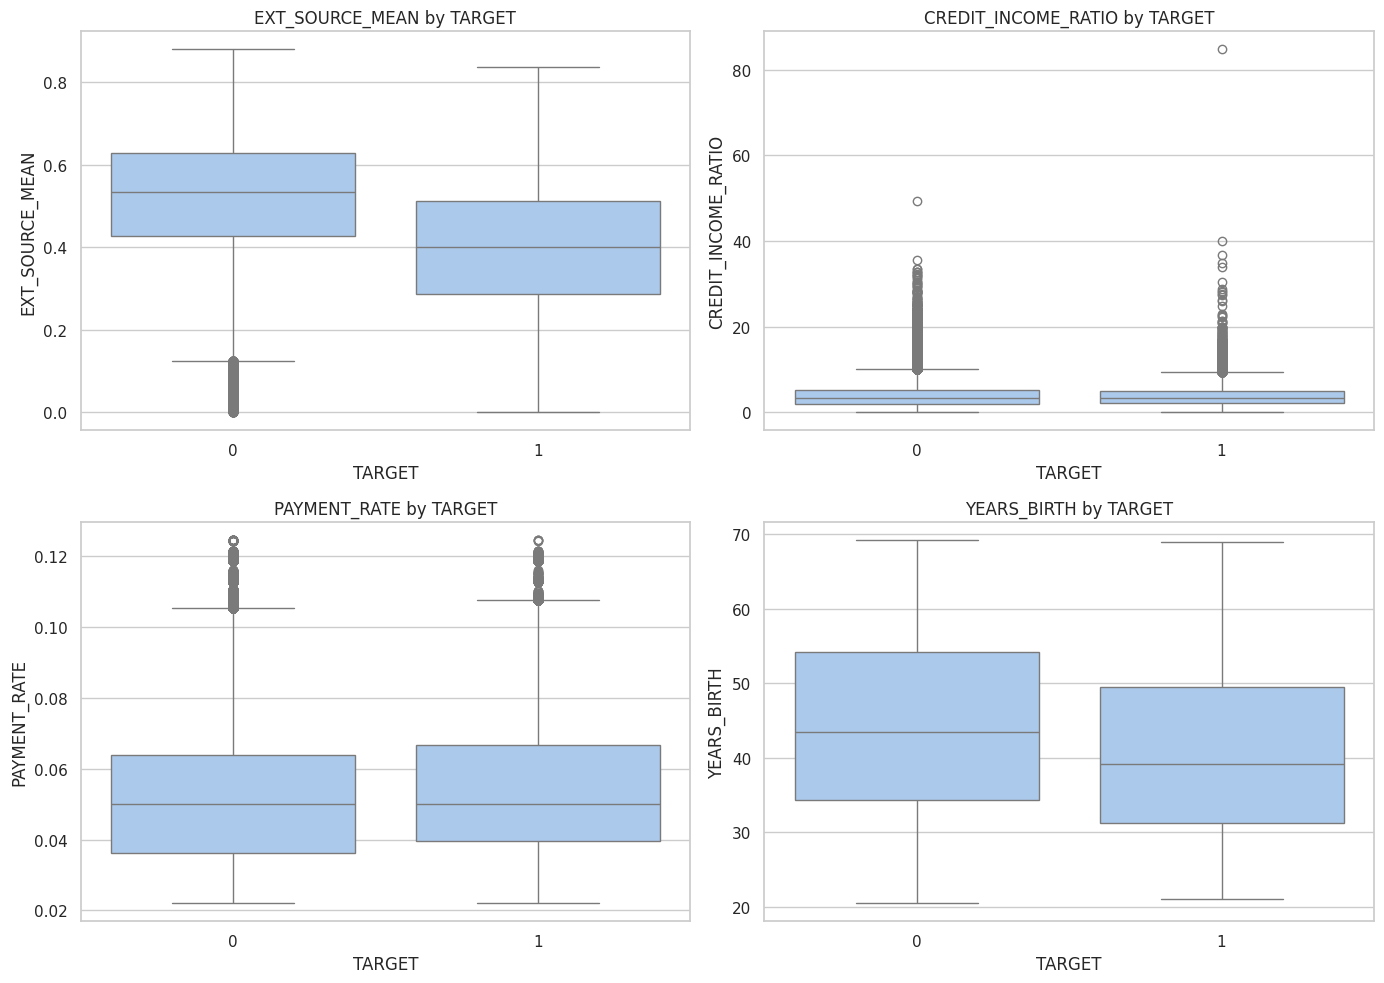

In [35]:
# Short numeric view by target
plot_features = [
    c for c in [
        "EXT_SOURCE_MEAN", "CREDIT_INCOME_RATIO", "PAYMENT_RATE", "YEARS_BIRTH"
    ] if c in train_fe.columns
]

if len(plot_features) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, col in zip(axes, plot_features):
        sns.boxplot(data=train_fe, x="TARGET", y=col, ax=ax)
        ax.set_title(f"{col} by TARGET")

    # Hide unused axes if any
    for ax in axes[len(plot_features):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

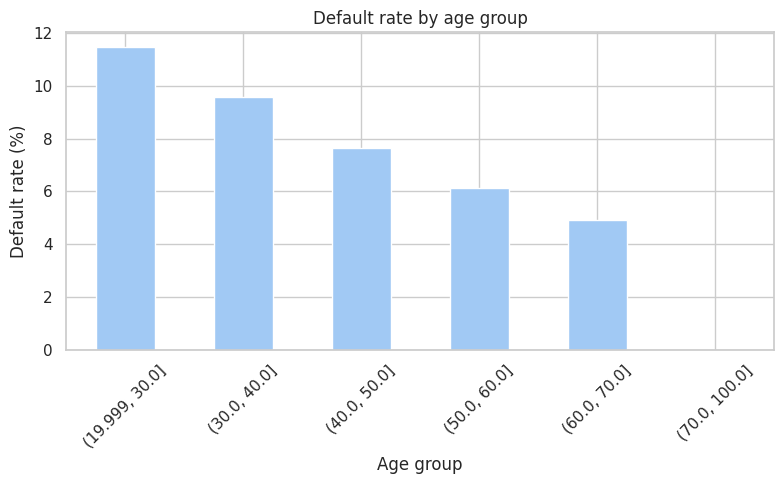

In [36]:
# Age group default rate
if "YEARS_BIRTH" in train_fe.columns:
    age_bins = pd.cut(
        train_fe["YEARS_BIRTH"],
        bins=[20, 30, 40, 50, 60, 70, 100],
        include_lowest=True
    )
    age_default = train_fe.groupby(age_bins)["TARGET"].mean().mul(100)

    plt.figure(figsize=(8, 5))
    age_default.plot(kind="bar")
    plt.title("Default rate by age group")
    plt.xlabel("Age group")
    plt.ylabel("Default rate (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

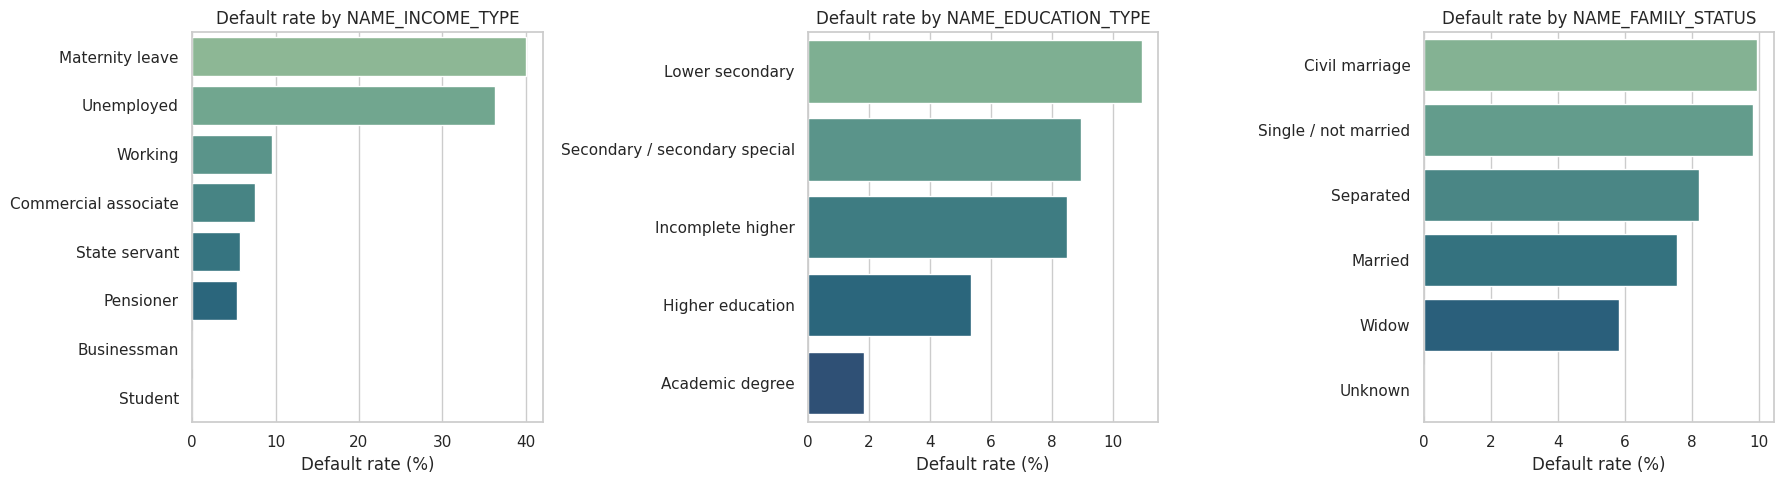

In [37]:
# Categorical default-rate plots
cat_candidates = [c for c in [
    "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS"
] if c in train_fe.columns]

if len(cat_candidates) > 0:
    fig, axes = plt.subplots(1, len(cat_candidates), figsize=(6 * len(cat_candidates), 5))
    if len(cat_candidates) == 1:
        axes = [axes]

    for ax, col in zip(axes, cat_candidates):
        default_rate = (
            train_fe.groupby(col)["TARGET"]
            .mean()
            .sort_values(ascending=False)
            .head(10)
            .mul(100)
        )
        sns.barplot(x=default_rate.values, y=default_rate.index, ax=ax, palette="crest")
        ax.set_title(f"Default rate by {col}")
        ax.set_xlabel("Default rate (%)")
        ax.set_ylabel("")

    plt.tight_layout()
    plt.show()

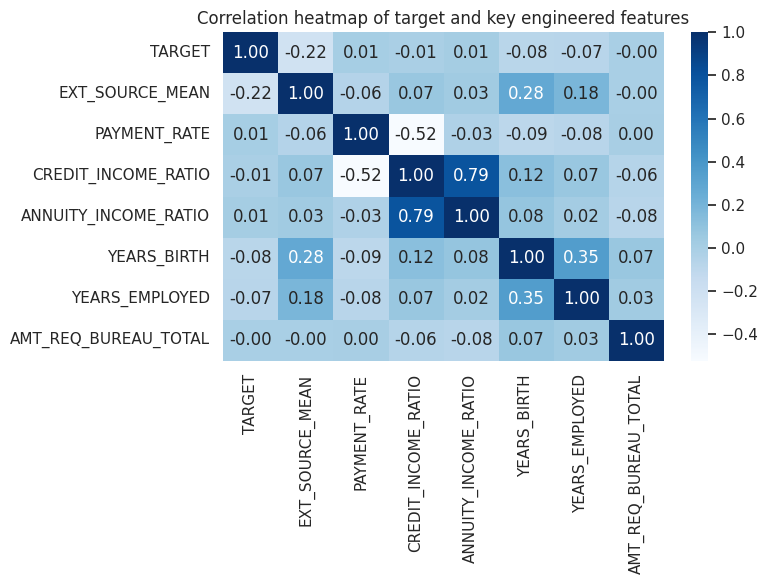

In [38]:
# Correlation heatmap for a few stronger engineered variables.
corr_candidates = [c for c in [
    "TARGET", "EXT_SOURCE_MEAN", "PAYMENT_RATE", "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO", "YEARS_BIRTH", "YEARS_EMPLOYED", "AMT_REQ_BUREAU_TOTAL"
] if c in train_fe.columns]

if len(corr_candidates) >= 3:
    plt.figure(figsize=(8, 6))
    corr = train_fe[corr_candidates].corr()
    sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
    plt.title("Correlation heatmap of target and key engineered features")
    plt.tight_layout()
    plt.show()

## 5. Preprocessing

**Idea:** create missing flags, drop very sparse columns, fill missing values, encode categoricals, and align train/test features.

In [39]:
# Missing flags for columns with at least 1% missing values
missing_ratio_before = train_fe.isna().mean()
cols_to_flag = [
    c for c in missing_ratio_before[missing_ratio_before > 0.01].index
    if c != "TARGET"
]

for col in cols_to_flag:
    train_fe[f"{col}_MISSING"] = train_fe[col].isna().astype(int)
    if col in test_fe.columns:
        test_fe[f"{col}_MISSING"] = test_fe[col].isna().astype(int)

# Drop very high missing columns
high_missing_cols = [
    c for c in train_fe.columns
    if train_fe[c].isna().mean() > 0.60 and c not in ["TARGET", "SK_ID_CURR"]
]
train_fe = train_fe.drop(columns=high_missing_cols)
test_fe = test_fe.drop(columns=[c for c in high_missing_cols if c in test_fe.columns])

# Fill missing values
num_cols = train_fe.select_dtypes(include=np.number).columns.tolist()
cat_cols = train_fe.select_dtypes(include=["object"]).columns.tolist()

for col in num_cols:
    fill_value = train_fe[col].median()
    train_fe[col] = train_fe[col].fillna(fill_value)
    if col in test_fe.columns:
        test_fe[col] = test_fe[col].fillna(fill_value)

for col in cat_cols:
    train_fe[col] = train_fe[col].fillna("missing")
    if col in test_fe.columns:
        test_fe[col] = test_fe[col].fillna("missing")

# Label encode categoricals using train + test together
categorical_features = train_fe.select_dtypes(include=["object"]).columns.tolist()
for col in categorical_features:
    le = preprocessing.LabelEncoder()
    combined = list(train_fe[col].astype(str).values) + list(test_fe[col].astype(str).values)
    le.fit(combined)
    train_fe[col] = le.transform(train_fe[col].astype(str).values)
    test_fe[col] = le.transform(test_fe[col].astype(str).values)

# Force numeric and remove constant columns
train_fe = train_fe.apply(pd.to_numeric, errors="coerce")
test_fe = test_fe.apply(pd.to_numeric, errors="coerce")

constant_cols = [c for c in train_fe.columns if train_fe[c].nunique(dropna=False) <= 1]
train_fe = train_fe.drop(columns=constant_cols)
test_fe = test_fe.drop(columns=[c for c in constant_cols if c in test_fe.columns])

# Build modeling matrices
drop_cols = ["TARGET", "SK_ID_CURR"]
X = train_fe.drop(columns=[c for c in drop_cols if c in train_fe.columns])
y = train_fe["TARGET"].copy()
X_test = test_fe.drop(columns=[c for c in drop_cols if c in test_fe.columns], errors="ignore")
X_test = X_test.reindex(columns=X.columns, fill_value=-999)

prep_summary = pd.DataFrame({
    "metric": [
        "missing_flag_columns",
        "high_missing_columns_dropped",
        "constant_columns_dropped",
        "final_feature_count",
        "train_rows",
        "test_rows"
    ],
    "value": [
        len(cols_to_flag),
        len(high_missing_cols),
        len(constant_cols),
        X.shape[1],
        X.shape[0],
        X_test.shape[0]
    ]
})
display(prep_summary)

,metric,value
0,missing_flag_columns,61
1,high_missing_columns_dropped,17
2,constant_columns_dropped,0
3,final_feature_count,191
4,train_rows,307511
5,test_rows,307511


## 6. Feature selection

**Idea:** use Random Forest importance to keep the strongest 95% cumulative importance features and reduce noise.

,feature,importance,cumulative_importance
0,EXT_SOURCE_MEAN,0.234473,0.234473
1,EXT_SOURCE_MIN,0.110233,0.344705
2,EXT_SOURCE_MAX,0.060484,0.405190
3,EXT_SOURCE_PROD,0.059353,0.464543
4,GOODS_CREDIT_RATIO,0.045806,0.510349
5,EXT_SOURCE_3,0.029492,0.539840
6,DAYS_EMPLOYED_RATIO,0.018365,0.558206
7,EXT_SOURCE_2,0.017325,0.575531
8,EXT_SOURCE_STD,0.016640,0.592170
9,PAYMENT_RATE,0.016140,0.608311


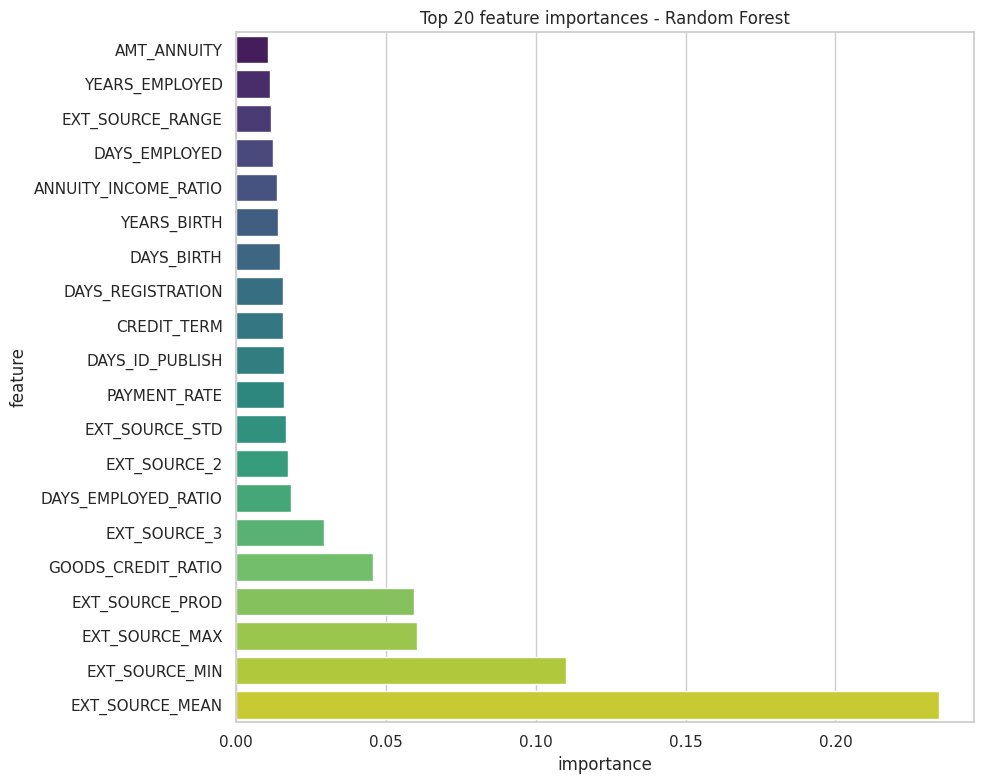

Selected feature count: 65


In [40]:
rf = RandomForestClassifier(
    n_estimators=80,
    max_depth=10,
    min_samples_leaf=4,
    max_features=0.5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X, y)

feature_importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": rf.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
feature_importance["cumulative_importance"] = feature_importance["importance"].cumsum()

display(feature_importance.head(20))

selected_features = feature_importance.loc[
    feature_importance["cumulative_importance"] <= 0.95, "feature"
].tolist()

if len(selected_features) < 25:
    # Keep a healthy minimum so the selected set does not become too small.
    selected_features = feature_importance.head(40)["feature"].tolist()

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(20).sort_values("importance"),
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Top 20 feature importances - Random Forest")
plt.tight_layout()
plt.show()

print("Selected feature count:", len(selected_features))

In [41]:
X_selected = X[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X_selected, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Logistic Regression needs scaling. Tree models do not.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)

# Practical tuning subset: keeps search realistic on larger data.
TUNING_SAMPLE_MAX = 12000
if len(X_train) > TUNING_SAMPLE_MAX:
    tune_frame = X_train.copy()
    tune_frame["_target_"] = y_train.values
    tune_frame = (
        tune_frame.groupby("_target_", group_keys=False)
        .apply(lambda g: g.sample(
            n=min(len(g), max(1, int(round(TUNING_SAMPLE_MAX * len(g) / len(X_train))))),
            random_state=RANDOM_STATE
        ))
        .sample(frac=1.0, random_state=RANDOM_STATE)
    )
    y_train_tune = tune_frame.pop("_target_").astype(int)
    X_train_tune = tune_frame.copy()
else:
    X_train_tune = X_train.copy()
    y_train_tune = y_train.copy()

print("Tuning sample size:", X_train_tune.shape)


Train size: (246008, 65)
Validation size: (61503, 65)
Tuning sample size: (12000, 65)


## 7. Hyperparameter tuning

**Why this section matters:** the earlier version used manually chosen model settings.  
This final version adds a more formal search strategy:

- **LightGBM:** `GridSearchCV` with a compact grid, following the style of the uploaded example notebook
- **XGBoost:** `RandomizedSearchCV` so the search stays practical
- **Logistic Regression:** `GridSearchCV` on a scaled pipeline

**Scoring choice:** all searches optimize **ROC-AUC** because the problem is imbalanced and ROC-AUC is a strong ranking metric for credit-risk screening.


In [42]:
# Grid / randomized search based tuning
USE_HYPERPARAM_TUNING = True
CV_FOLDS = 3
tuning_cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

tuned_params = {}
tuning_summary_rows = []

def record_search_result(model_name, search_obj):
    tuning_summary_rows.append({
        "model": model_name,
        "search_type": type(search_obj).__name__,
        "best_cv_roc_auc": round(float(search_obj.best_score_), 5),
        "best_params": str(search_obj.best_params_)
    })

if USE_HYPERPARAM_TUNING:
    # --- LightGBM: compact grid search (same spirit as the uploaded example) ---
    lgb_base = lgb.LGBMClassifier(
        objective="binary",
        is_unbalance=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    lgb_param_grid = {
        "num_leaves": [31, 50],
        "max_depth": [-1, 10],
        "learning_rate": [0.01, 0.05, 0.10],
        "n_estimators": [100, 300, 500]
    }
    lgb_search = GridSearchCV(
        estimator=lgb_base,
        param_grid=lgb_param_grid,
        scoring="roc_auc",
        cv=tuning_cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )
    lgb_search.fit(X_train_tune, y_train_tune)
    tuned_params["LightGBM"] = lgb_search.best_params_
    record_search_result("LightGBM", lgb_search)

    # --- XGBoost: randomized search to keep runtime more practical ---
    xgb_scale_pos_weight = float((y_train_tune == 0).sum() / max((y_train_tune == 1).sum(), 1))
    xgb_base = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=xgb_scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    xgb_param_dist = {
        "n_estimators": [200, 300, 500, 700],
        "learning_rate": [0.01, 0.03, 0.05, 0.10],
        "max_depth": [3, 4, 5, 6, 8],
        "min_child_weight": [1, 2, 4, 6],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "gamma": [0.0, 0.1, 0.3, 1.0],
        "reg_alpha": [0.0, 0.01, 0.1, 1.0],
        "reg_lambda": [0.5, 1.0, 3.0, 5.0]
    }
    xgb_search = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=xgb_param_dist,
        n_iter=18,
        scoring="roc_auc",
        cv=tuning_cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True
    )
    xgb_search.fit(X_train_tune, y_train_tune)
    tuned_params["XGBoost"] = xgb_search.best_params_
    record_search_result("XGBoost", xgb_search)

    # --- Logistic Regression: grid search on a scaled pipeline ---
    logreg_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ])
    logreg_param_grid = {
        "clf__C": [0.01, 0.05, 0.10, 0.50, 1.0, 3.0],
        "clf__solver": ["liblinear", "lbfgs"],
        "clf__class_weight": [None, "balanced"]
    }
    logreg_search = GridSearchCV(
        estimator=logreg_pipe,
        param_grid=logreg_param_grid,
        scoring="roc_auc",
        cv=tuning_cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )
    logreg_search.fit(X_train_tune, y_train_tune)
    tuned_params["Logistic Regression"] = {
        k.replace("clf__", ""): v for k, v in logreg_search.best_params_.items()
    }
    record_search_result("Logistic Regression", logreg_search)

    tuning_summary_df = pd.DataFrame(tuning_summary_rows).sort_values(
        "best_cv_roc_auc", ascending=False
    ).reset_index(drop=True)
    display(tuning_summary_df)

else:
    tuning_summary_df = pd.DataFrame()
    print("Hyperparameter tuning skipped; manual defaults will be used.")


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Fitting 3 folds for each of 24 candidates, totalling 72 fits


,model,search_type,best_cv_roc_auc,best_params
0,Logistic Regression,GridSearchCV,0.72791,"{'clf__C': 0.01, 'clf__class_weight': 'balance..."
1,XGBoost,RandomizedSearchCV,0.71685,"{'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alp..."
2,LightGBM,GridSearchCV,0.70145,"{'learning_rate': 0.01, 'max_depth': -1, 'n_es..."


## 8. Tuned model training and hold-out evaluation

This section rebuilds the three models using the **best tuned parameters** from the search step above, then evaluates them on the fixed hold-out validation split.  
That keeps the workflow cleaner:

1. tune on the training portion only  
2. rebuild each model with best parameters  
3. evaluate once on the untouched validation split


In [43]:
def build_models_from_params():
    lgb_params = tuned_params.get("LightGBM", {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1
    })
    xgb_params = tuned_params.get("XGBoost", {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 1,
        "gamma": 0.0,
        "reg_alpha": 0.0,
        "reg_lambda": 1.0,
    })
    logreg_params = tuned_params.get("Logistic Regression", {
        "C": 1.0,
        "solver": "lbfgs",
        "class_weight": "balanced"
    })

    return {
        "LightGBM": lgb.LGBMClassifier(
            **lgb_params,
            objective="binary",
            is_unbalance=True,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        ),
        "XGBoost": xgb.XGBClassifier(
            **xgb_params,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=float((y_train == 0).sum() / max((y_train == 1).sum(), 1)),
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "Logistic Regression": LogisticRegression(
            **logreg_params,
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    }

models = build_models_from_params()

def find_best_threshold(y_true, y_prob):
    rows = []
    for t in np.arange(0.10, 0.91, 0.05):
        y_pred = (y_prob >= t).astype(int)
        rows.append({
            "threshold": round(float(t), 2),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)
        })
    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]
    return threshold_df, float(best_row["threshold"])

def evaluate_model(name, model):
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_prob = model.predict_proba(X_val_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_val)[:, 1]

    y_pred_default = (y_prob >= 0.50).astype(int)
    threshold_df, best_threshold = find_best_threshold(y_val, y_prob)
    y_pred_best = (y_prob >= best_threshold).astype(int)

    metrics = {
        "model": name,
        "roc_auc": roc_auc_score(y_val, y_prob),
        "pr_auc": average_precision_score(y_val, y_prob),
        "best_threshold": best_threshold,
        "f1_default": f1_score(y_val, y_pred_default, zero_division=0),
        "f1_best": f1_score(y_val, y_pred_best, zero_division=0),
        "precision_best": precision_score(y_val, y_pred_best, zero_division=0),
        "recall_best": recall_score(y_val, y_pred_best, zero_division=0),
    }

    fpr, tpr, _ = roc_curve(y_val, y_prob)
    precision, recall, _ = precision_recall_curve(y_val, y_prob)

    return {
        "name": name,
        "model": model,
        "y_prob": y_prob,
        "y_pred_default": y_pred_default,
        "y_pred_best": y_pred_best,
        "metrics": metrics,
        "threshold_df": threshold_df,
        "roc_curve": (fpr, tpr),
        "pr_curve": (precision, recall)
    }

eval_outputs = {}
for name, model in models.items():
    eval_outputs[name] = evaluate_model(name, model)

results_df = pd.DataFrame([v["metrics"] for v in eval_outputs.values()]).sort_values(
    "roc_auc", ascending=False
).reset_index(drop=True)

display(results_df)


,model,roc_auc,pr_auc,best_threshold,f1_default,f1_best,precision_best,recall_best
0,XGBoost,0.751909,0.241156,0.65,0.262282,0.302911,0.236830,0.420141
1,Logistic Regression,0.747960,0.235203,0.65,0.260332,0.297978,0.227028,0.433434
2,LightGBM,0.747454,0.227777,0.45,0.264228,0.296889,0.233522,0.407452


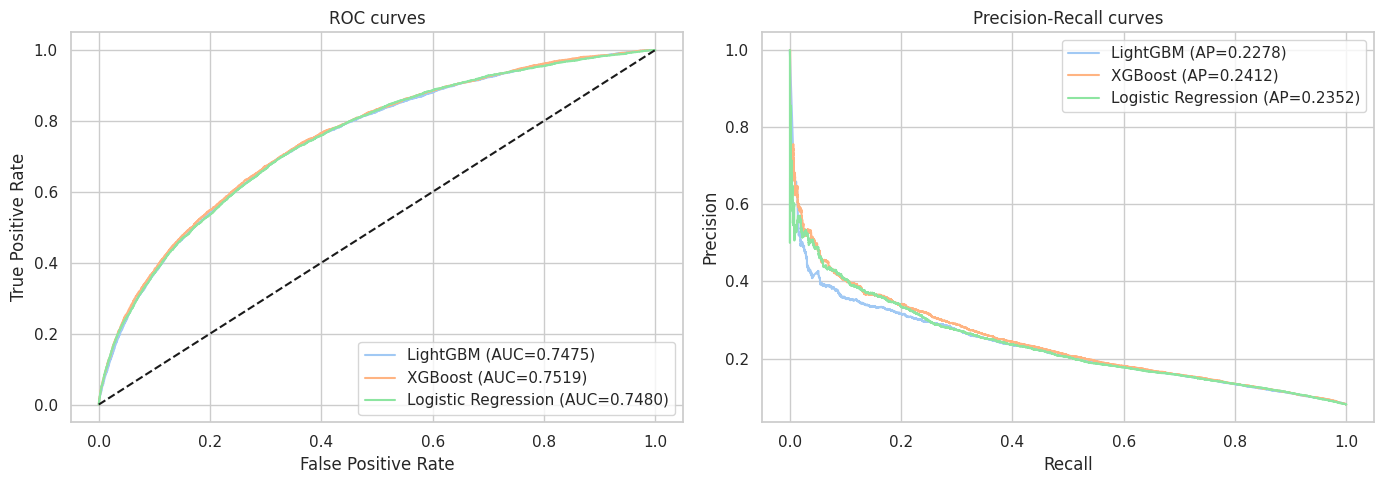

In [44]:
# Combined ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in eval_outputs.items():
    fpr, tpr = res["roc_curve"]
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['metrics']['roc_auc']:.4f})")

    precision, recall = res["pr_curve"]
    axes[1].plot(recall, precision, label=f"{name} (AP={res['metrics']['pr_auc']:.4f})")

axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("ROC curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].set_title("Precision-Recall curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

In [45]:
# Classification reports shown clearly model by model
for name, res in eval_outputs.items():
    display(Markdown(f"### {name}"))
    print("Default threshold = 0.50")
    print(classification_report(y_val, res["y_pred_default"], zero_division=0))
    print(f"Best threshold = {res['metrics']['best_threshold']:.2f}")
    print(classification_report(y_val, res["y_pred_best"], zero_division=0))

### LightGBM

Default threshold = 0.50
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     56538
           1       0.30      0.24      0.26      4965

    accuracy                           0.89     61503
   macro avg       0.62      0.59      0.60     61503
weighted avg       0.88      0.89      0.89     61503

Best threshold = 0.45
              precision    recall  f1-score   support

           0       0.94      0.88      0.91     56538
           1       0.23      0.41      0.30      4965

    accuracy                           0.84     61503
   macro avg       0.59      0.65      0.60     61503
weighted avg       0.89      0.84      0.86     61503



### XGBoost

Default threshold = 0.50
              precision    recall  f1-score   support

           0       0.96      0.69      0.81     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.69      0.53     61503
weighted avg       0.90      0.69      0.76     61503

Best threshold = 0.65
              precision    recall  f1-score   support

           0       0.95      0.88      0.91     56538
           1       0.24      0.42      0.30      4965

    accuracy                           0.84     61503
   macro avg       0.59      0.65      0.61     61503
weighted avg       0.89      0.84      0.86     61503



### Logistic Regression

Default threshold = 0.50
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503

Best threshold = 0.65
              precision    recall  f1-score   support

           0       0.95      0.87      0.91     56538
           1       0.23      0.43      0.30      4965

    accuracy                           0.84     61503
   macro avg       0.59      0.65      0.60     61503
weighted avg       0.89      0.84      0.86     61503



## 9. Confusion matrices

**Idea:** show confusion matrices at the default threshold and also at the best F1 threshold for each model.

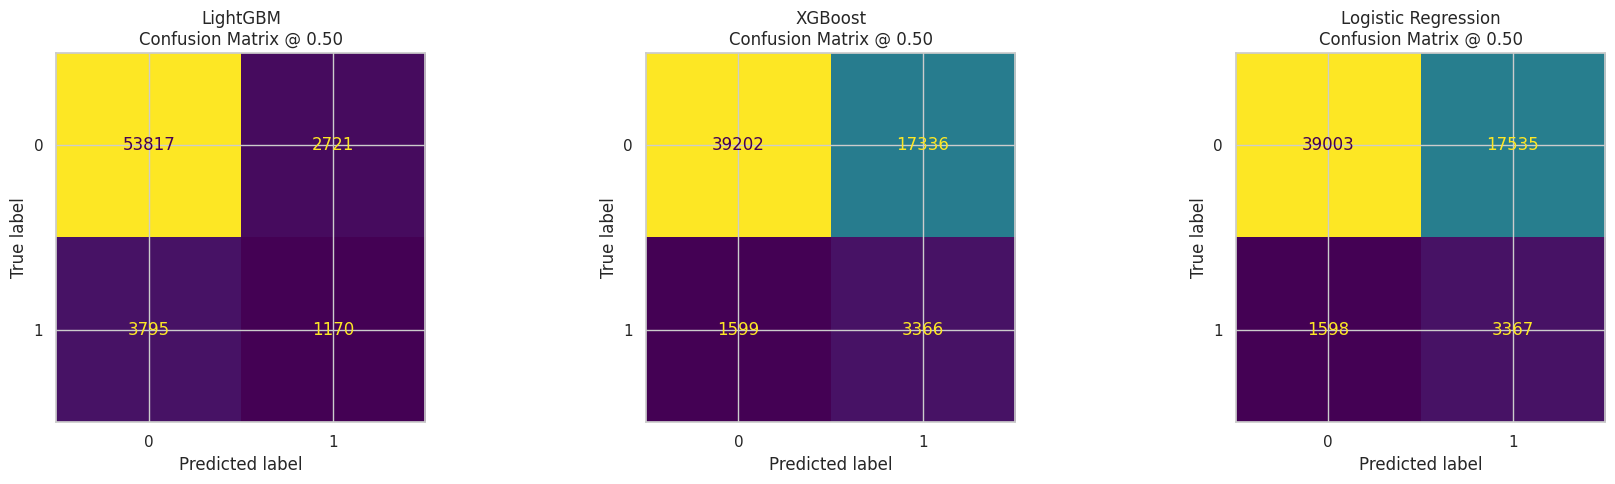

In [46]:
# Default-threshold confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, eval_outputs.items()):
    cm = confusion_matrix(y_val, res["y_pred_default"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{name}\nConfusion Matrix @ 0.50")
plt.tight_layout()
plt.show()

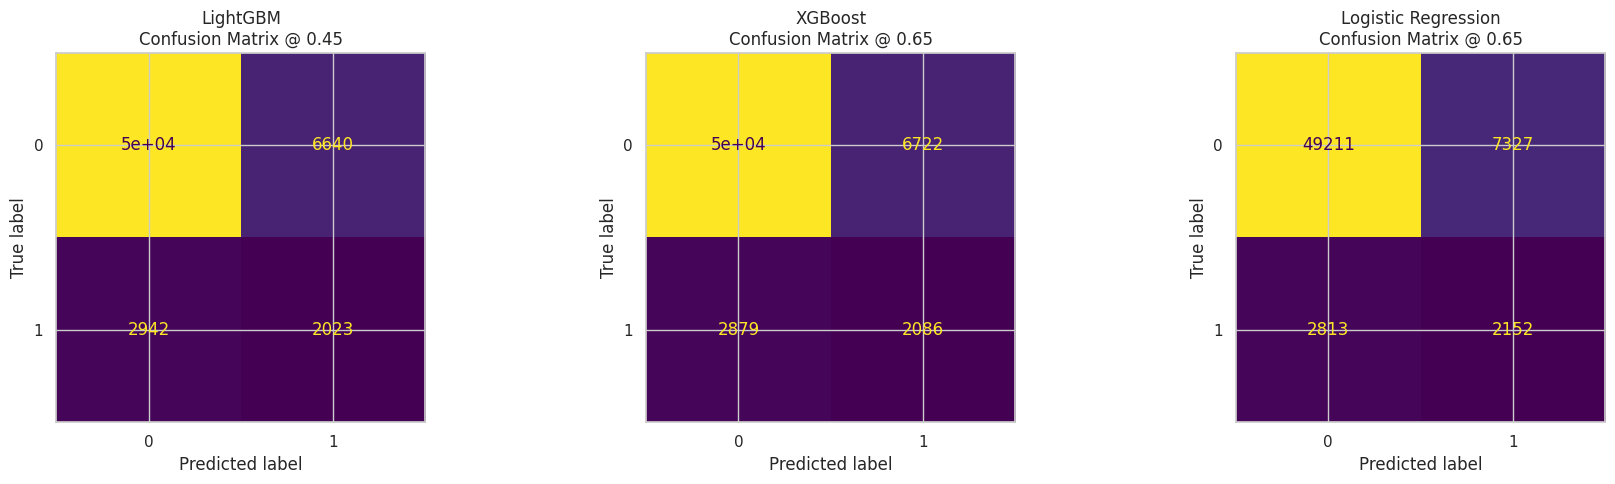

In [47]:
# Best-threshold confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, eval_outputs.items()):
    cm = confusion_matrix(y_val, res["y_pred_best"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{name}\nConfusion Matrix @ {res['metrics']['best_threshold']:.2f}")
plt.tight_layout()
plt.show()

## 10. Threshold behavior

**Idea:** this section shows how precision, recall, and F1 change across thresholds so the final cutoff is easier to justify.

**Best validation ROC-AUC model:** XGBoost

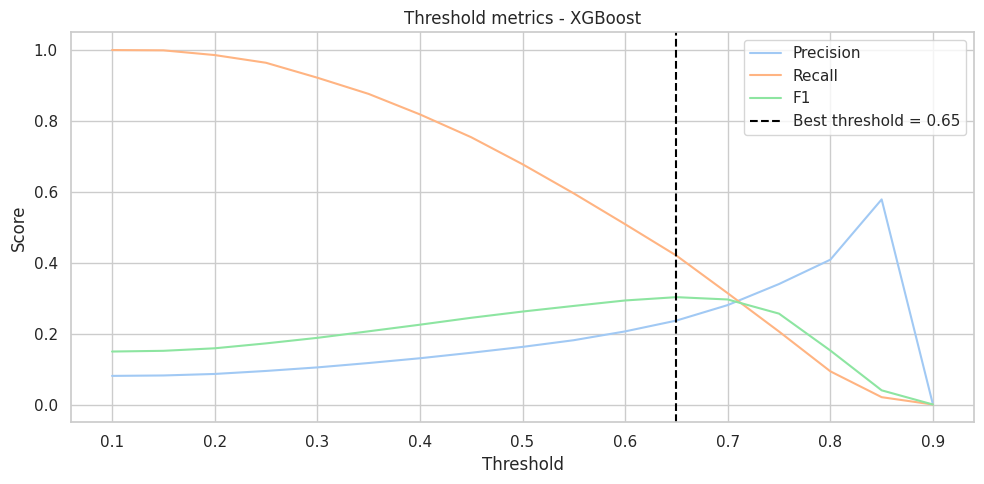

,threshold,precision,recall,f1
0,0.10,0.080786,1.000000,0.149494
1,0.15,0.081972,0.999194,0.151513
2,0.20,0.086254,0.985901,0.158630
3,0.25,0.094711,0.964149,0.172480
4,0.30,0.104729,0.922054,0.188093
5,0.35,0.117066,0.876334,0.206541
6,0.40,0.130549,0.818530,0.225184
7,0.45,0.146050,0.754079,0.244706
8,0.50,0.162593,0.677946,0.262282
9,0.55,0.181467,0.595569,0.278175


In [48]:
best_model_name = results_df.iloc[0]["model"]
best_res = eval_outputs[best_model_name]

display(Markdown(f"**Best validation ROC-AUC model:** {best_model_name}"))

plt.figure(figsize=(10, 5))
threshold_df = best_res["threshold_df"]
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(best_res["metrics"]["best_threshold"], linestyle="--", color="black",
            label=f"Best threshold = {best_res['metrics']['best_threshold']:.2f}")
plt.title(f"Threshold metrics - {best_model_name}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

display(threshold_df)

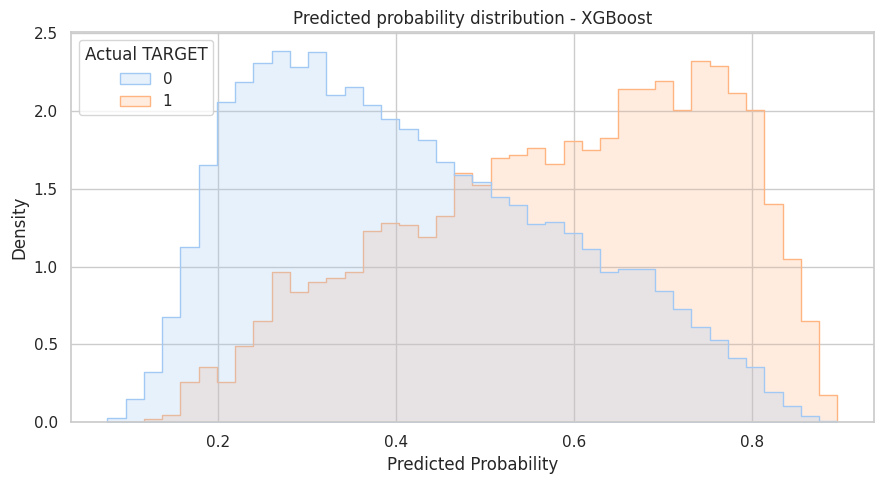

In [49]:
# Probability separation plot for the best model
prob_df = pd.DataFrame({
    "Actual TARGET": y_val.values,
    "Predicted Probability": best_res["y_prob"]
})

plt.figure(figsize=(9, 5))
sns.histplot(
    data=prob_df,
    x="Predicted Probability",
    hue="Actual TARGET",
    bins=40,
    element="step",
    stat="density",
    common_norm=False
)
plt.title(f"Predicted probability distribution - {best_model_name}")
plt.tight_layout()
plt.show()

## 11. Learning curves

**Idea:** learning curves show whether the model is improving with more data or starting to level off.

**Note:** to keep runtime practical, the plot uses a sampled training subset when the dataset is very large.

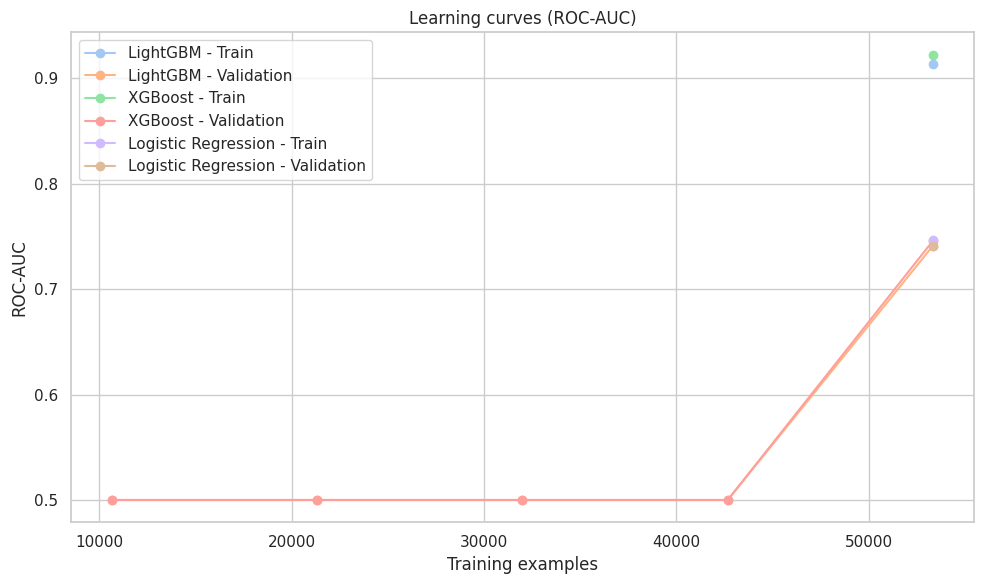

In [50]:
def plot_learning_curve_for_model(name, model, X_data, y_data, scaled=False, max_samples=80000):
    # Sample rows for plotting only, so this section stays practical on large data.
    if len(X_data) > max_samples:
        sample_idx = pd.Series(y_data).groupby(y_data).sample(
            frac=max_samples / len(X_data),
            random_state=RANDOM_STATE
        ).index
        X_plot = X_data.loc[sample_idx]
        y_plot = y_data.loc[sample_idx]
    else:
        X_plot = X_data.copy()
        y_plot = y_data.copy()

    if scaled:
        X_used = StandardScaler().fit_transform(X_plot)
    else:
        X_used = X_plot

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_used,
        y_plot,
        cv=3,
        scoring="roc_auc",
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.plot(train_sizes, train_mean, marker="o", label=f"{name} - Train")
    plt.plot(train_sizes, val_mean, marker="o", label=f"{name} - Validation")

plt.figure(figsize=(10, 6))
plot_learning_curve_for_model(
    "LightGBM",
    lgb.LGBMClassifier(n_estimators=250, learning_rate=0.05, is_unbalance=True, random_state=RANDOM_STATE),
    X_selected, y, scaled=False
)
plot_learning_curve_for_model(
    "XGBoost",
    xgb.XGBClassifier(n_estimators=250, learning_rate=0.05, max_depth=6, eval_metric="logloss", random_state=RANDOM_STATE),
    X_selected, y, scaled=False
)
plot_learning_curve_for_model(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    X_selected, y, scaled=True
)

plt.title("Learning curves (ROC-AUC)")
plt.xlabel("Training examples")
plt.ylabel("ROC-AUC")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Cross-validation discussion

A single train/validation split is useful, but cross-validation gives a stronger view of stability.  
This section adds two checks:

1. **5-fold ROC-AUC comparison across all tuned models**
2. **out-of-fold AUC check for the strongest tuned tree model**

That directly addresses the reviewer feedback that the notebook needed a clearer cross-validation discussion.


In [51]:
# 5-fold CV comparison across all tuned models
CV_SAMPLE_MAX = 15000
if len(X_selected) > CV_SAMPLE_MAX:
    cv_frame = X_selected.copy()
    cv_frame["_target_"] = y.values
    cv_frame = (
        cv_frame.groupby("_target_", group_keys=False)
        .apply(lambda g: g.sample(
            n=min(len(g), max(1, int(round(CV_SAMPLE_MAX * len(g) / len(X_selected))))),
            random_state=RANDOM_STATE
        ))
        .sample(frac=1.0, random_state=RANDOM_STATE)
    )
    y_cv = cv_frame.pop("_target_").astype(int)
    X_cv = cv_frame.copy()
else:
    X_cv = X_selected.copy()
    y_cv = y.copy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def build_model_for_cv(name):
    if name == "Logistic Regression":
        p = tuned_params.get("Logistic Regression", {
            "C": 1.0,
            "solver": "lbfgs",
            "class_weight": "balanced"
        })
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, **p))
        ])
    elif name == "LightGBM":
        p = tuned_params.get("LightGBM", {
            "n_estimators": 300, "learning_rate": 0.05, "num_leaves": 31, "max_depth": -1
        })
        return lgb.LGBMClassifier(
            **p, objective="binary", is_unbalance=True,
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
        )
    else:
        p = tuned_params.get("XGBoost", {
            "n_estimators": 500, "learning_rate": 0.05, "max_depth": 6,
            "subsample": 0.8, "colsample_bytree": 0.8
        })
        scale_pos_weight = float((y_cv == 0).sum() / max((y_cv == 1).sum(), 1))
        return xgb.XGBClassifier(
            **p, objective="binary:logistic", eval_metric="logloss",
            scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=-1
        )

cv_rows = []
for model_name in ["Logistic Regression", "LightGBM", "XGBoost"]:
    cv_model = build_model_for_cv(model_name)
    scores = cross_val_score(
        cv_model, X_cv, y_cv,
        cv=skf, scoring="roc_auc", n_jobs=-1
    )
    cv_rows.append({
        "model": model_name,
        "cv_mean_auc": round(float(scores.mean()), 5),
        "cv_std_auc": round(float(scores.std()), 5),
        "fold_1": round(float(scores[0]), 5),
        "fold_2": round(float(scores[1]), 5),
        "fold_3": round(float(scores[2]), 5),
        "fold_4": round(float(scores[3]), 5),
        "fold_5": round(float(scores[4]), 5),
    })

cv_comparison_df = pd.DataFrame(cv_rows).sort_values("cv_mean_auc", ascending=False).reset_index(drop=True)
display(cv_comparison_df)

# Out-of-fold check for the strongest tuned tree model
tree_results = results_df[results_df["model"].isin(["LightGBM", "XGBoost"])].sort_values("roc_auc", ascending=False)
strongest_tree_model_name = tree_results.iloc[0]["model"]
print("Strongest tuned tree model based on validation ROC-AUC:", strongest_tree_model_name)

oof_preds = np.zeros(len(X_cv))
fold_rows = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    model = build_model_for_cv(strongest_tree_model_name)
    X_tr, X_va = X_cv.iloc[tr_idx], X_cv.iloc[va_idx]
    y_tr, y_va = y_cv.iloc[tr_idx], y_cv.iloc[va_idx]

    model.fit(X_tr, y_tr)
    y_va_prob = model.predict_proba(X_va)[:, 1]
    oof_preds[va_idx] = y_va_prob
    fold_auc = roc_auc_score(y_va, y_va_prob)
    fold_rows.append({"fold": fold, "auc": round(float(fold_auc), 5)})

cv_fold_df = pd.DataFrame(fold_rows)
display(cv_fold_df)
print("OOF ROC-AUC:", round(float(roc_auc_score(y_cv, oof_preds)), 5))


,model,cv_mean_auc,cv_std_auc,fold_1,fold_2,fold_3,fold_4,fold_5
0,Logistic Regression,0.74431,0.01025,0.73847,0.72816,0.75269,0.75691,0.74530
1,XGBoost,0.73930,0.00883,0.72799,0.72983,0.74751,0.74204,0.74914
2,LightGBM,0.72950,0.00924,0.71314,0.72865,0.73571,0.72953,0.74046


Strongest tuned tree model based on validation ROC-AUC: XGBoost


,fold,auc
0,1,0.72799
1,2,0.72983
2,3,0.74751
3,4,0.74204
4,5,0.74914


OOF ROC-AUC: 0.73885


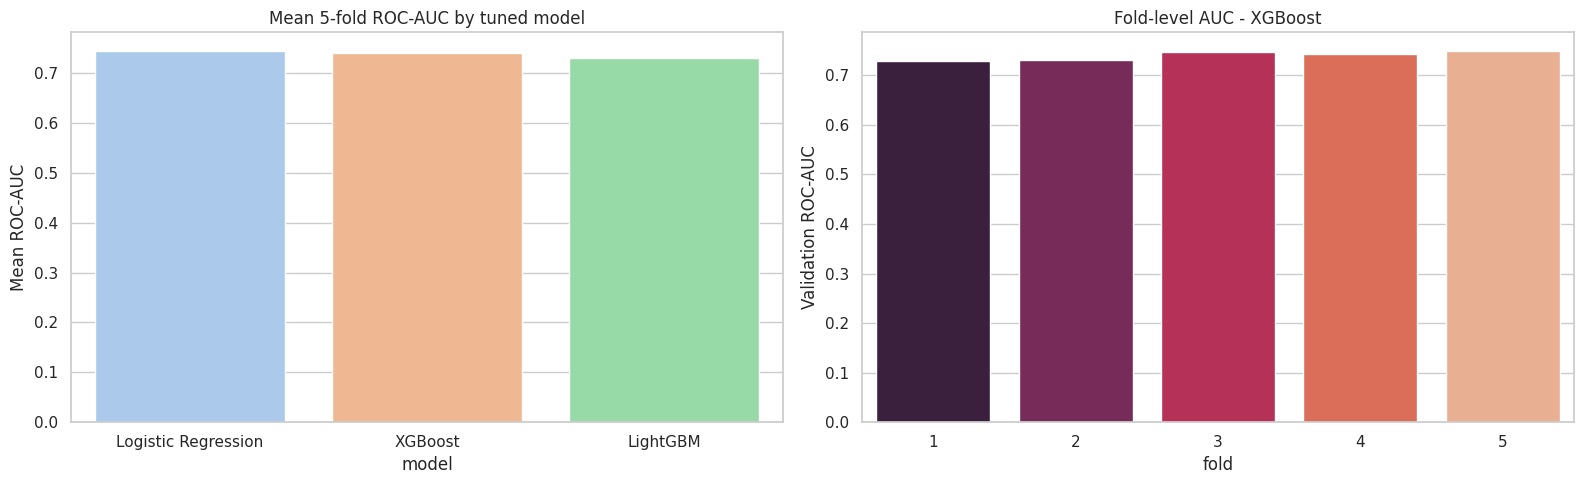

In [52]:
# Visual summary of cross-validation stability
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=cv_comparison_df, x="model", y="cv_mean_auc", ax=axes[0], palette="pastel")
axes[0].set_title("Mean 5-fold ROC-AUC by tuned model")
axes[0].set_ylabel("Mean ROC-AUC")

sns.barplot(data=cv_fold_df, x="fold", y="auc", ax=axes[1], palette="rocket")
axes[1].set_title(f"Fold-level AUC - {strongest_tree_model_name}")
axes[1].set_ylabel("Validation ROC-AUC")

plt.tight_layout()
plt.show()


## 13. SHAP interpretation and final tree-model importance

The reviewer feedback asked for deeper explainability.  
This section adds:

1. **SHAP summary plot** for the strongest tuned tree model  
2. **one local SHAP waterfall explanation** for a single validation case  
3. **feature-importance ranking** for reporting


SHAP summary for: XGBoost


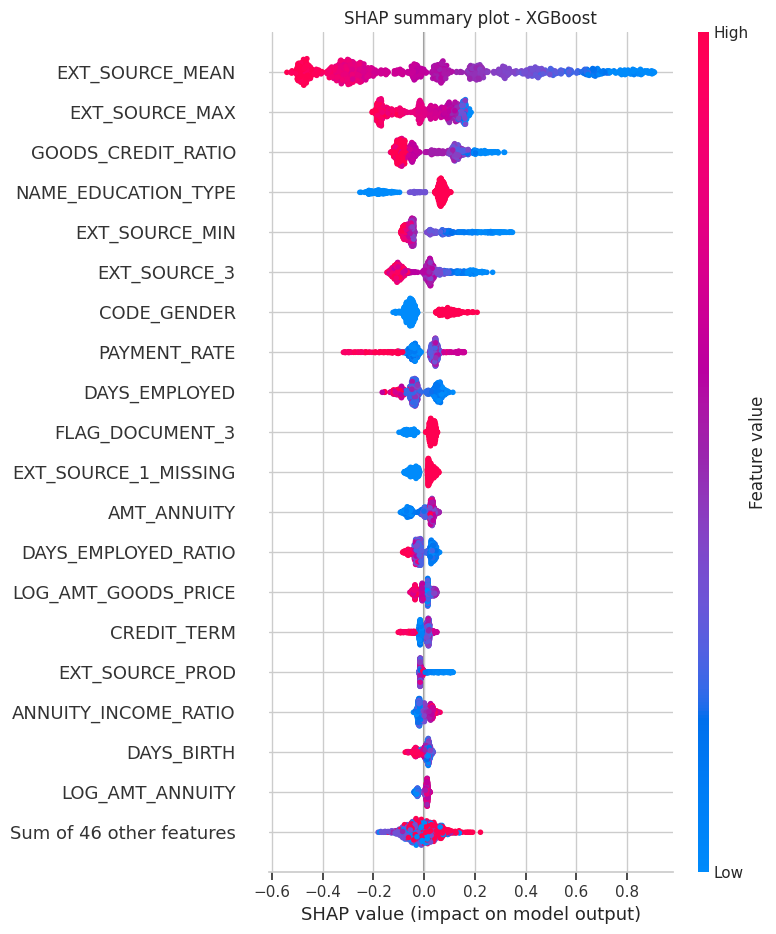

Local SHAP explanation for one example borrower


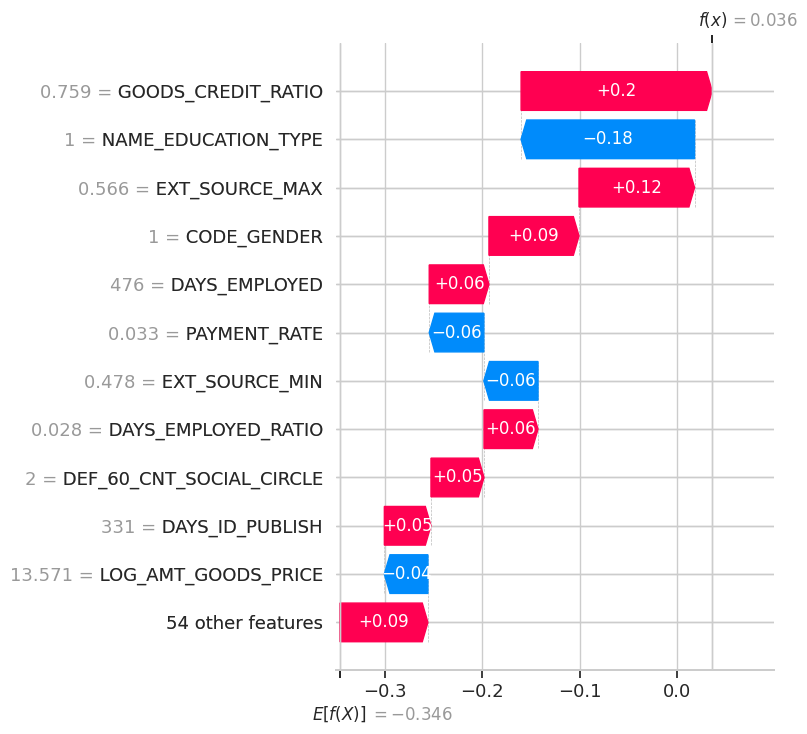

,feature,importance
0,EXT_SOURCE_MEAN,0.167198
1,EXT_SOURCE_MIN,0.112898
2,EXT_SOURCE_MAX,0.080446
3,EXT_SOURCE_PROD,0.033086
5,EXT_SOURCE_3,0.032670
8,EXT_SOURCE_STD,0.029938
28,NAME_EDUCATION_TYPE,0.024106
16,DAYS_EMPLOYED,0.023955
36,CODE_GENDER,0.021422
11,CREDIT_TERM,0.020487


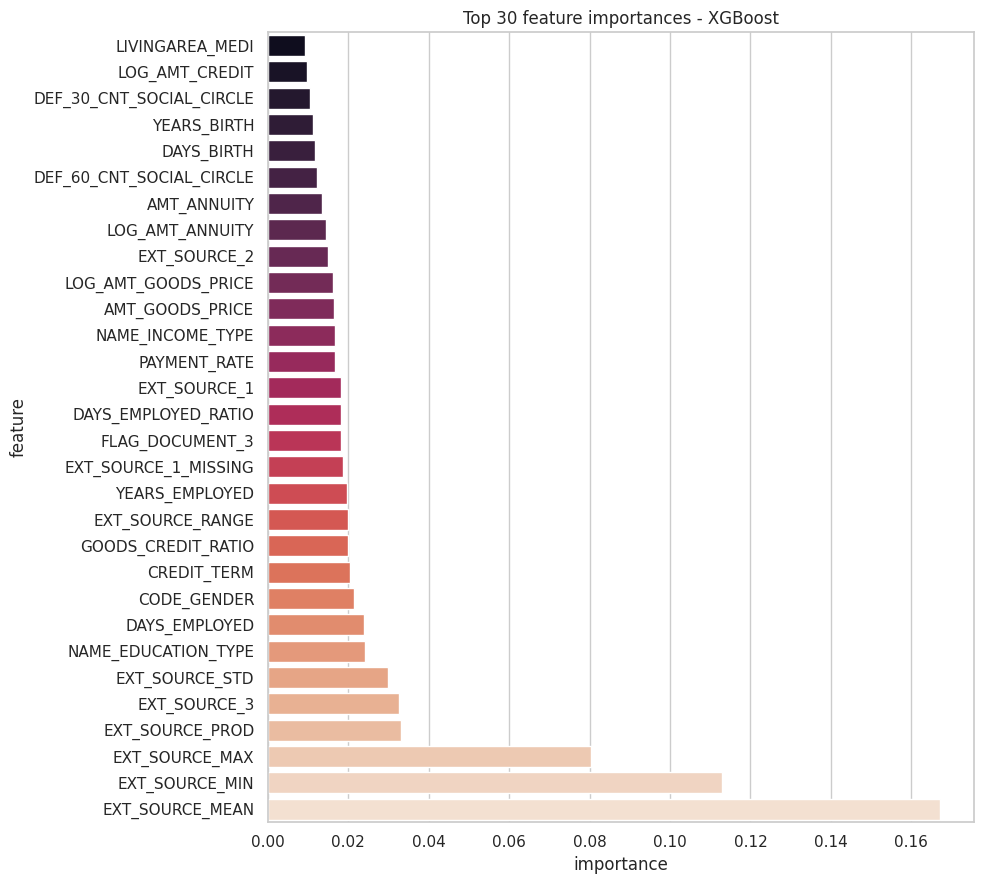

In [53]:
# Fit the strongest tuned tree model on the training split
strongest_tree_model = build_model_for_cv(strongest_tree_model_name)
strongest_tree_model.fit(X_train, y_train)

# --- SHAP interpretation ---
SHAP_BACKGROUND_MAX = 500
SHAP_EXPLAIN_MAX = 1000

background = X_train.sample(n=min(SHAP_BACKGROUND_MAX, len(X_train)), random_state=RANDOM_STATE)
to_explain = X_val.sample(n=min(SHAP_EXPLAIN_MAX, len(X_val)), random_state=RANDOM_STATE)

try:
    explainer = shap.Explainer(strongest_tree_model, background)
    shap_values = explainer(to_explain)

    print("SHAP summary for:", strongest_tree_model_name)
    shap.plots.beeswarm(shap_values, max_display=20, show=False)
    plt.title(f"SHAP summary plot - {strongest_tree_model_name}")
    plt.tight_layout()
    plt.show()

    print("Local SHAP explanation for one example borrower")
    shap.plots.waterfall(shap_values[0], max_display=12, show=False)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("SHAP could not be generated automatically:", e)

# --- final tree-model importance ---
if hasattr(strongest_tree_model, "feature_importances_"):
    final_importance = (
        pd.DataFrame({
            "feature": X_train.columns,
            "importance": strongest_tree_model.feature_importances_
        })
        .sort_values("importance", ascending=False)
        .head(30)
    )

    display(final_importance.head(15))

    plt.figure(figsize=(10, 9))
    sns.barplot(
        data=final_importance.sort_values("importance"),
        x="importance",
        y="feature",
        palette="rocket"
    )
    plt.title(f"Top 30 feature importances - {strongest_tree_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print(f"{strongest_tree_model_name} does not expose feature_importances_ in the expected way.")
